In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import datetime as dt

In [2]:
load_path = Path("../../data/combined/done_week_45")
save_path = Path("../../data/combined")

In [3]:
sold = pd.read_parquet(load_path/"sold.parquet")

In [4]:
sold.columns

Index(['OriginalListPrice', 'CloseDate', 'ClosePrice', 'Latitude', 'Longitude',
       'LivingArea', 'ListPrice', 'DaysOnMarket', 'AssociationFeeFrequency',
       'CountyOrParish', 'ParkingTotal', 'PropertySubType', 'YearBuilt',
       'BathroomsTotalInteger', 'City', 'BedroomsTotal', 'StateOrProvince',
       'FireplaceYN', 'Levels', 'LotSizeArea', 'MainLevelBedrooms',
       'NewConstructionYN', 'GarageSpaces', 'PostalCode', 'AssociationFee',
       'PurchaseContractDate', 'ListingContractDate',
       'ContractStatusChangeDate', 'rate_30yr_fixed', 'ViewYN',
       'PoolPrivateYN', 'MLSAreaMajor', 'ListOfficeName', 'BuyerOfficeName',
       'listing_after_close_flag', 'purchase_after_close_flag',
       'geographic_error'],
      dtype='str')

In [5]:
fe_sold = sold.copy()

fe_sold["PriceRatio"] = np.where(
    fe_sold["OriginalListPrice"] > 0,
    fe_sold["ClosePrice"] / fe_sold["OriginalListPrice"],
    np.nan)
fe_sold["PricePerSqFt"] = np.where(
    fe_sold["LivingArea"] > 0,
    fe_sold["ClosePrice"] / fe_sold["LivingArea"],
    np.nan)

fe_sold["PriceRatio"] = fe_sold["ClosePrice"] / fe_sold["OriginalListPrice"]
fe_sold["PricePerSqFt"] = fe_sold["ClosePrice"] / fe_sold["LivingArea"]

fe_sold["Year"] = fe_sold["CloseDate"].dt.year
fe_sold["Month"] = fe_sold["CloseDate"].dt.month
fe_sold["Year"] = fe_sold["Year"].astype('Int64')
fe_sold["Month"] = fe_sold["Month"].astype('Int64')
fe_sold["YrMo"] = fe_sold["Year"].astype(str) + "-" + fe_sold["Month"].astype(str)

fe_sold["ListingToContractDays"] = (fe_sold["PurchaseContractDate"] - fe_sold["ListingContractDate"]).dt.days
fe_sold["ContractToCloseDays"] = (fe_sold["CloseDate"] - fe_sold["PurchaseContractDate"]).dt.days
fe_sold["ListingToContractDays"] = fe_sold["ListingToContractDays"].astype('Int64')
fe_sold["ContractToCloseDays"] = fe_sold["ContractToCloseDays"].astype('Int64')

<Axes: ylabel='PropertySubType'>

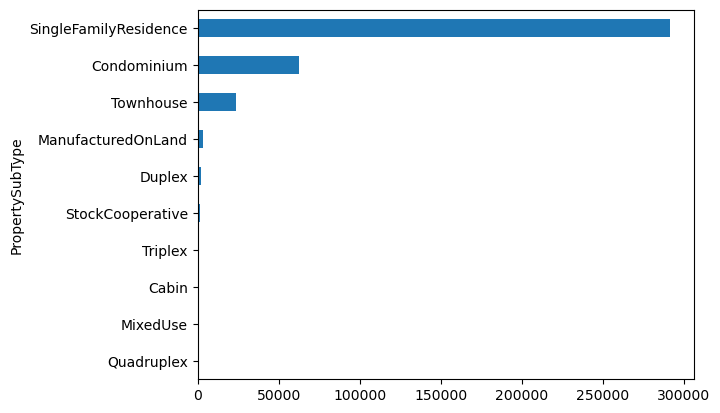

In [6]:
fe_sold["PropertySubType"].value_counts().head(10).sort_values().plot.barh()

<Axes: ylabel='CountyOrParish'>

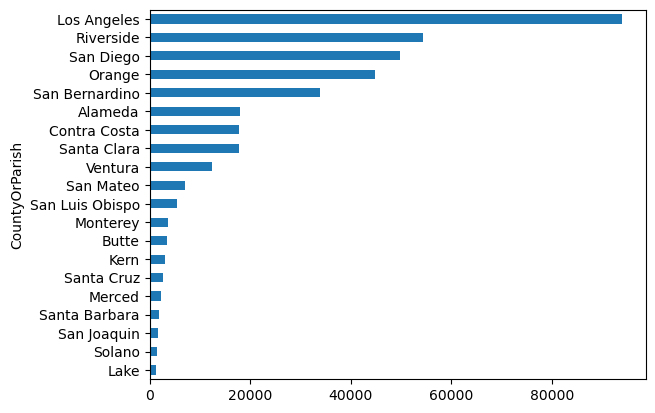

In [7]:
fe_sold["CountyOrParish"].value_counts().head(20).sort_values().plot.barh()

<Axes: ylabel='MLSAreaMajor'>

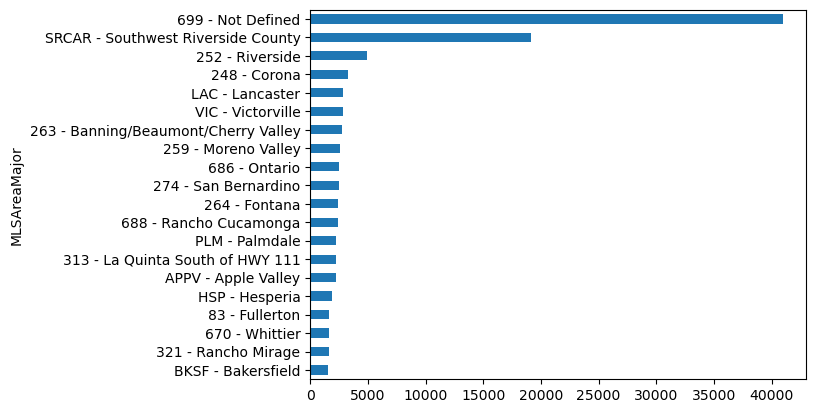

In [8]:
fe_sold["MLSAreaMajor"].value_counts().head(20).sort_values().plot.barh()

<Axes: ylabel='ListOfficeName'>

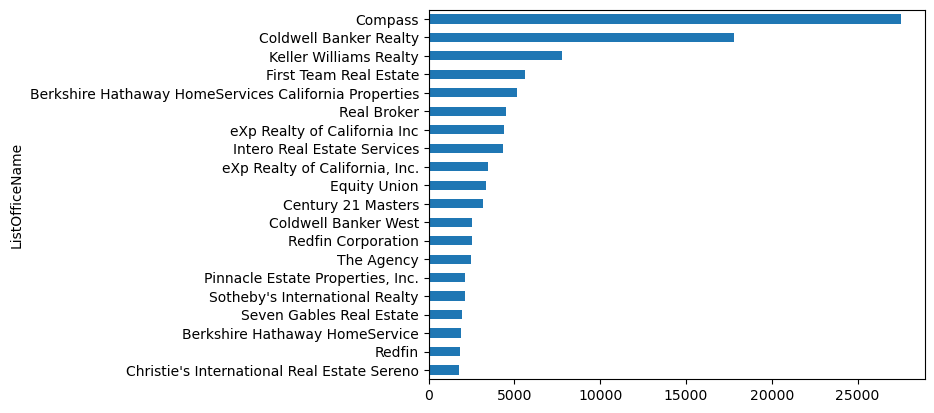

In [9]:
fe_sold["ListOfficeName"].value_counts().head(20).sort_values().plot.barh()

<Axes: ylabel='BuyerOfficeName'>

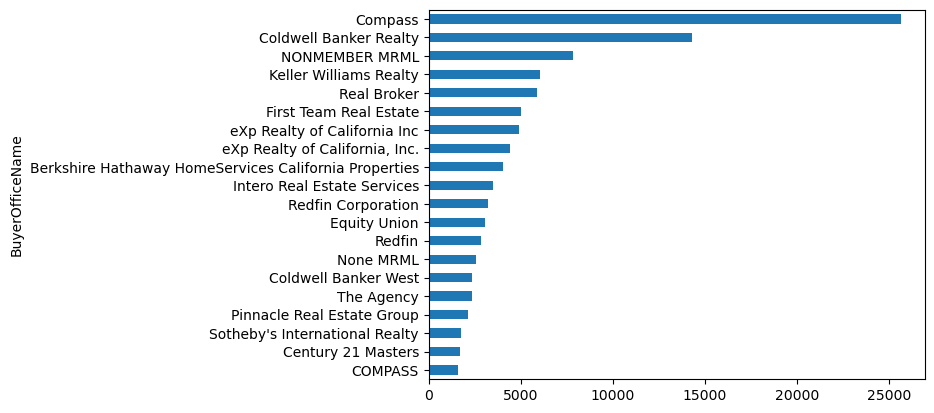

In [10]:
fe_sold["BuyerOfficeName"].value_counts().head(20).sort_values().plot.barh()

In [11]:
summary_by_PropertySubType = (
    fe_sold
    .groupby("PropertySubType")
    .agg(
        listing_count=("PropertySubType", "size"),
        avg_close_price=("ClosePrice", "mean"),
        median_close_price=("ClosePrice", "median"),
        avg_price_per_sqft=("PricePerSqFt", "mean"),
        avg_price_ratio=("PriceRatio", "mean"),
        avg_days_on_market=("DaysOnMarket", "mean"),
        avg_listing_to_contract_days=("ListingToContractDays", "mean"),
        avg_contract_to_close_days=("ContractToCloseDays", "mean")
    )
    .sort_values("listing_count", ascending=False)
)

summary_by_PropertySubType.head(10)

,listing_count,avg_close_price,median_close_price,avg_price_per_sqft,avg_price_ratio,avg_days_on_market,avg_listing_to_contract_days,avg_contract_to_close_days
PropertySubType,,,,,,,,
SingleFamilyResidence,291399,1.315483e+06,905000.0,641.466899,inf,35.485115,43.577521,31.315409
Condominium,62683,8.752861e+05,640000.0,689.525144,26.369728,40.817239,47.704176,30.934055
Townhouse,23711,1.023533e+06,809000.0,664.772382,42.505957,31.953735,38.27313,30.923976
ManufacturedOnLand,3301,3.857934e+05,350000.0,257.677171,1.505057,56.425629,66.356862,40.045138
Duplex,1851,1.318066e+06,965000.0,676.220401,1.538644,41.267423,53.837385,37.397083
StockCooperative,1169,4.004059e+05,370000.0,407.780132,0.973103,38.344739,48.112917,46.794696
Triplex,233,1.416127e+06,1200000.0,563.839233,1.020693,59.712446,72.381974,47.497854
Cabin,133,4.085547e+05,310000.0,343.882027,0.900313,63.842105,73.578947,35.736842
MixedUse,128,1.202442e+06,839500.0,540.813438,0.897433,86.585938,99.5,42.6875


In [12]:
summary_by_CountyOrParish = (
    fe_sold
    .groupby("CountyOrParish")
    .agg(
        listing_count=("CountyOrParish", "size"),
        avg_close_price=("ClosePrice", "mean"),
        median_close_price=("ClosePrice", "median"),
        avg_price_per_sqft=("PricePerSqFt", "mean"),
        avg_price_ratio=("PriceRatio", "mean"),
        avg_days_on_market=("DaysOnMarket", "mean"),
        avg_listing_to_contract_days=("ListingToContractDays", "mean"),
        avg_contract_to_close_days=("ContractToCloseDays", "mean")
    )
    .sort_values("listing_count", ascending=False)
)

summary_by_CountyOrParish.head(10)

,listing_count,avg_close_price,median_close_price,avg_price_per_sqft,avg_price_ratio,avg_days_on_market,avg_listing_to_contract_days,avg_contract_to_close_days
CountyOrParish,,,,,,,,
Los Angeles,93936,1.333937e+06,915000.0,684.815213,109.272289,35.852485,44.313627,33.761736
Riverside,54409,7.335568e+05,610000.0,354.149254,inf,47.916815,59.134763,32.166041
San Diego,49787,1.481348e+06,900000.0,888.447211,1.418024,29.399361,38.007332,29.364387
Orange,44926,1.567362e+06,1200000.0,775.258175,80.272046,31.146062,42.760979,30.893311
San Bernardino,33992,6.274825e+05,554000.0,355.048909,64.659423,43.567810,52.67158,36.834702
Alameda,17952,1.299174e+06,1170000.0,743.941520,1.200514,25.204880,26.143215,25.57236
Contra Costa,17807,1.152419e+06,840000.0,585.487581,1.058589,28.568877,29.826248,26.029034
Santa Clara,17740,1.933828e+06,1600000.0,1065.532968,1.042146,21.482244,21.592897,26.506201
Ventura,12458,1.080182e+06,870000.0,618.672697,1.496595,42.765131,51.697447,25.407178


In [13]:
summary_by_BuyerOfficeName = (
    fe_sold
    .groupby("BuyerOfficeName")
    .agg(
        listing_count=("CountyOrParish", "size"),
        avg_close_price=("ClosePrice", "mean"),
        median_close_price=("ClosePrice", "median"),
        avg_price_per_sqft=("PricePerSqFt", "mean"),
        avg_price_ratio=("PriceRatio", "mean"),
        avg_days_on_market=("DaysOnMarket", "mean"),
        avg_listing_to_contract_days=("ListingToContractDays", "mean"),
        avg_contract_to_close_days=("ContractToCloseDays", "mean")
    )
    .sort_values("listing_count", ascending=False)
)

summary_by_BuyerOfficeName.head(10)

,listing_count,avg_close_price,median_close_price,avg_price_per_sqft,avg_price_ratio,avg_days_on_market,avg_listing_to_contract_days,avg_contract_to_close_days
BuyerOfficeName,,,,,,,,
Compass,25664,1.811851e+06,1350000.0,852.932162,1.596542,31.676551,37.32717,27.060074
Coldwell Banker Realty,14289,1.687933e+06,1200000.0,826.390729,1.279128,34.048079,40.833754,27.360364
NONMEMBER MRML,7843,6.687570e+05,526000.0,366.229333,inf,47.494199,56.954609,37.188958
Keller Williams Realty,6076,1.297245e+06,850000.0,807.344399,1.782688,34.175115,42.514074,29.814321
Real Broker,5875,1.037431e+06,810000.0,586.470395,1.176408,32.924936,43.552605,29.989105
First Team Real Estate,5040,1.110883e+06,915000.0,617.122254,194.579944,30.778968,42.115324,30.253474
eXp Realty of California Inc,4896,1.068049e+06,850000.0,623.914275,1.199809,36.118056,43.014916,30.45709
"eXp Realty of California, Inc.",4443,1.006955e+06,745000.0,636.958758,1.251187,33.457349,42.868332,30.637182
Berkshire Hathaway HomeServices California Properties,4024,1.479698e+06,985000.0,701.643802,1.220910,38.087724,46.136703,29.649651


In [14]:
fe_sold.to_parquet(save_path/"sold_fe.parquet")